In [1]:
import sys
sys.path.append('..')

In [ ]:
from forecast.data import *
from config import *
import matplotlib.pyplot as plt
import torch.nn as nn

In [14]:
data_path = "../"+ config.DL_SSTA_DAILY_PATH
landmask_path = "../"+ config.DL_LANDMASK_PATH

In [15]:
ds = xr.open_zarr(str(data_path))

In [16]:
ds

<xarray.Dataset> Size: 4GB
Dimensions:    (time: 15566, lat: 180, lon: 360)
Coordinates:
  * time       (time) datetime64[ns] 125kB 1981-09-01 1981-09-02 ... 2026-04-14
  * lat        (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon        (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
    dayofyear  (time) int64 125kB dask.array<chunksize=(365,), meta=np.ndarray>
Data variables:
    ssta       (time, lat, lon) float32 4GB dask.array<chunksize=(365, 180, 360), meta=np.ndarray>

In [20]:
ds = SSTADataset(data_path, landmask_path, time_range=('1982-01-01', '2000-12-31'))

In [24]:
x, y = ds[0]
print(x.shape, y.shape)

torch.Size([14, 180, 360]) torch.Size([1, 180, 360])


In [ ]:
loader = DataLoader(ds, batch_size=4, shuffle=True,  drop_last=True)

In [29]:
x_ld, y_ld = next(iter(loader))

In [31]:
x_ld.shape, y_ld.shape

(torch.Size([4, 14, 180, 360]), torch.Size([4, 1, 180, 360]))

In [51]:
from forecast import model
model = PixelLSTM()

In [52]:
out = model(x_ld)

In [53]:
out.shape, y_ld.shape

(torch.Size([4, 1, 180, 360]), torch.Size([4, 1, 180, 360]))

In [46]:
diff = out - y_ld

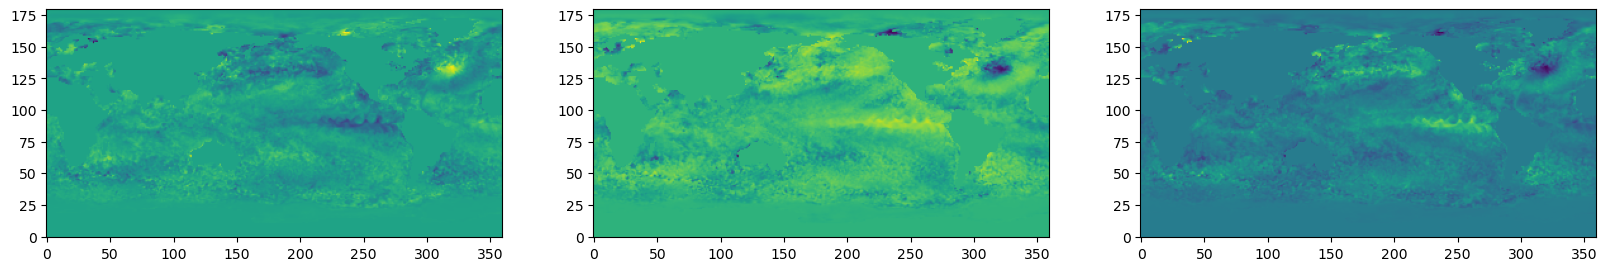

In [50]:
plt.figure(figsize=(20,10))
plt.subplot(131)
plt.imshow(y_ld[0,0], origin='lower')
plt.subplot(132)
plt.imshow(out[0,0].detach(), origin='lower')
plt.subplot(133)
plt.imshow(diff[0,0].detach(), origin='lower')

In [57]:
def masked_mse(pred: torch.Tensor, target: torch.Tensor, ocean_mask: torch.Tensor) -> torch.Tensor:
    """MSE over ocean cells only. Land should be removed

    pred, target: (B, n_out, H, W)
    ocean_mask:   (1, 1, H, W) — 1 over ocean, 0 over land
    """
    diff2 = (pred - target) ** 2 * ocean_mask
    denom = ocean_mask.sum() * pred.shape[0] * pred.shape[1]
    return diff2.sum() / denom.clamp(min=1.0)


In [62]:
mse = masked_mse(out, torch.tensor(y_ld), torch.tensor(ds.land_mask))

/tmp/ipykernel_4702/3071404356.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse = masked_mse(out, torch.tensor(y_ld), torch.tensor(ds.land_mask))
